In [3]:
import pandas as pd
import os

SILVER_DIR = r"D:\DSS_CK\financial-fraud-dss\data\2_silver"

# Định nghĩa lại đường dẫn thực tế của bạn
paths = {
    'users': os.path.join(SILVER_DIR, 'users_cleaned.parquet'),
    'cards': os.path.join(SILVER_DIR, 'cards_cleaned.parquet'), # Kiểm tra xem là card_cleaned hay cards_cleaned
    'transactions': os.path.join(SILVER_DIR, 'transactions_cleaned_part_1.parquet'),
    'labels': os.path.join(SILVER_DIR, 'labels_cleaned.parquet'),
    'mcc': os.path.join(SILVER_DIR, 'mcc_cleaned.parquet')
}

print("=== KIỂM TRA CẤU TRÚC FILE PARQUET ===")
for name, path in paths.items():
    if os.path.exists(path):
        # Chỉ đọc 5 dòng đầu để xem cấu trúc cột cho nhẹ RAM
        df_temp = pd.read_parquet(path, engine='pyarrow').head(5)
        print(f"\n📌 FILE: {name.upper()} ({path})")
        print(f" -> Các cột: {list(df_temp.columns)}")
        print(f" -> Kiểu dữ liệu một số cột chính:\n{df_temp.dtypes.head(5)}")
    else:
        print(f"\n❌ Không tìm thấy file: {path}")

=== KIỂM TRA CẤU TRÚC FILE PARQUET ===

📌 FILE: USERS (D:\DSS_CK\financial-fraud-dss\data\2_silver\users_cleaned.parquet)
 -> Các cột: ['user_id', 'user_age', 'retirement_age', 'birth_year', 'birth_month', 'gender', 'address', 'latitude', 'longitude', 'per_capita_income', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards']
 -> Kiểu dữ liệu một số cột chính:
user_id           int64
user_age          int64
retirement_age    int64
birth_year        int64
birth_month       int64
dtype: object

📌 FILE: CARDS (D:\DSS_CK\financial-fraud-dss\data\2_silver\cards_cleaned.parquet)
 -> Các cột: ['card_id', 'user_id', 'card_brand', 'card_type', 'card_number', 'expires', 'cvv', 'has_chip', 'num_cards_issued', 'credit_limit', 'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web']
 -> Kiểu dữ liệu một số cột chính:
card_id        int64
user_id        int64
card_brand       str
card_type        str
card_number    int64
dtype: object

📌 FILE: TRANSACTIONS (D:\DSS_CK\financial-frau

In [4]:
import pandas as pd
import numpy as np
import os
import gc
import glob
from datetime import datetime

# ==========================================
# CẤU HÌNH ĐƯỜNG DẪN TỚI TẦNG SILVER
# ==========================================
# Thay đổi đường dẫn này trỏ tới thư mục 2_silver của dự án
SILVER_DIR = r"D:\DSS_CK\financial-fraud-dss\data\2_silver"
OUTPUT_FILE = r"D:\DSS_CK\financial-fraud-dss\data\featured_transactions_data.csv" # Hoặc lưu ở đâu tùy bạn

FAST_TRAIN_MODE = True  # Bật True để lấy mẫu nén RAM (Chống sập máy)
DOWNSAMPLE_RATIO = 20   # Tỷ lệ 1 gian lận : 20 hợp pháp

# ==========================================
# HÀM TỐI ƯU HOÁ BỘ NHỚ RAM 
# ==========================================
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and not isinstance(col_type, pd.CategoricalDtype) and not str(col_type).startswith('datetime'):
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)  
            elif str(col_type)[:5] == 'float':
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            # Bảo vệ các cột ID và Date không bị chuyển thành category
            if col.endswith('_id') or col == 'id' or col == 'transaction_id' or 'date' in col:
                df[col] = df[col].astype(str)
            else:
                num_unique = len(df[col].unique())
                if num_unique / len(df) < 0.5:
                    df[col] = df[col].astype('category')
    return df

# ==========================================
# HÀM NẠP TỰ ĐỘNG CÁC KHỐI PARQUET SẠCH
# ==========================================
def load_silver_parquet_data():
    print(f"\n[Bước 1.1] Đang quét và nạp dữ liệu sạch từ: {SILVER_DIR}...")
    
    # 1. Đọc bảng Users
    # Vũ đặt tên tọa độ là latitude, longitude -> ta đổi lại cho chuẩn nghiệp vụ
    cols_users = ['user_id', 'user_age', 'yearly_income', 'total_debt', 'credit_score', 'latitude', 'longitude']
    df_users = pd.read_parquet(os.path.join(SILVER_DIR, 'users_cleaned.parquet'), columns=cols_users)
    df_users.rename(columns={'latitude': 'user_lat', 'longitude': 'user_lon'}, inplace=True)
    df_users = reduce_mem_usage(df_users)
    
    # 2. Đọc bảng Cards
    cols_cards = ['card_id', 'user_id', 'card_type', 'credit_limit', 'card_on_dark_web', 'has_chip', 'acct_open_date', 'year_pin_last_changed']
    df_cards = pd.read_parquet(os.path.join(SILVER_DIR, 'cards_cleaned.parquet'), columns=cols_cards)
    df_cards = reduce_mem_usage(df_cards)
    
    # 3. Đọc linh hoạt TẤT CẢ các khối Transactions bằng Glob
    trans_pattern = os.path.join(SILVER_DIR, 'transactions_cleaned_part_*.parquet')
    trans_files = sorted(glob.glob(trans_pattern))
    print(f" -> Tự động phát hiện {len(trans_files)} khối dữ liệu transactions.")
    
    # Lưu ý: Cột is_fraud đã được Vũ gộp sẵn vào file transaction ở tầng ETL
    cols_trans = ['transaction_id', 'date', 'user_id', 'card_id', 'amount', 'use_chip', 'mcc', 'errors', 'merchant_state', 'merchant_id', 'is_fraud']
    
    # Check nếu có merch_lat/merch_long trong file
    temp_check = pd.read_parquet(trans_files[0])
    if 'merch_lat' in temp_check.columns:
        cols_trans.extend(['merch_lat', 'merch_long'])
        
    chunks = []
    for i, file_path in enumerate(trans_files):
        print(f"   + Đang nạp khối {i+1}/{len(trans_files)}...")
        chunk = pd.read_parquet(file_path, columns=cols_trans)
        
        # Đổi tên cột tọa độ Merchant cho đồng bộ
        if 'merch_lat' in chunk.columns:
            chunk.rename(columns={'merch_lat': 'merchant_lat', 'merch_long': 'merchant_lon'}, inplace=True)
        
        # Giảm mẫu trực tiếp trên RAM để không bị sập máy
        if FAST_TRAIN_MODE:
            fraud_chunk = chunk[chunk['is_fraud'] == 1]
            legit_chunk = chunk[chunk['is_fraud'] == 0]
            
            n_sample = len(fraud_chunk) * DOWNSAMPLE_RATIO
            if len(legit_chunk) > n_sample:
                legit_chunk = legit_chunk.sample(n=n_sample, random_state=42)
                
            chunk = pd.concat([fraud_chunk, legit_chunk], ignore_index=True)
            
        chunk = reduce_mem_usage(chunk)
        chunks.append(chunk)
        
    df_transactions = pd.concat(chunks, ignore_index=True)
    print(f" -> Tổng số dòng Transactions đã nạp vào RAM: {len(df_transactions):,}")
    
    return df_users, df_cards, df_transactions

# ==========================================
# LỚP FEATURE ENGINEERING (CẢI TIẾN)
# ==========================================
class RealDataFeatureEngineer:
    def __init__(self, df_users, df_cards, df_transactions):
        self.df_users = df_users
        self.df_cards = df_cards
        self.df_transactions = df_transactions

    def _join_data(self):
        # 1. Nối Transactions với Cards (Thông qua cặp khóa card_id, user_id)
        df = self.df_transactions.merge(
            self.df_cards, 
            on=['card_id', 'user_id'], 
            how='left'
        )
        del self.df_transactions
        gc.collect()

        # 2. Nối tiếp với Users (Thông qua khóa user_id)
        df = df.merge(
            self.df_users, 
            on='user_id', 
            how='left'
        )
        del self.df_users, self.df_cards
        gc.collect()

        return df

    def _haversine_distance(self, lat1, lon1, lat2, lon2):
        R = 6371
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        return (R * c).astype(np.float32)

    def build_features(self):
        print("\n[Bước 2.1] Đang khớp nối dữ liệu thô (Merge & Join)...")
        df = self._join_data()

        print("[Bước 2.2] Đang chuyển đổi định dạng ngày tháng...")
        df['date'] = pd.to_datetime(df['date']) # Parquet đã lưu chuẩn nên convert rất nhanh
        df['is_error_txn'] = df['errors'].notnull().astype(np.int8)

        # --- GIAI ĐOẠN 1: TÍNH TOÁN THEO THẺ (CARD-BASED) ---
        print("[Bước 2.3] Sắp xếp theo Thẻ & Thời gian để tính Card Features...")
        df = df.sort_values(['card_id', 'date']).reset_index(drop=True)

        df['flag_is_refund'] = (df['amount'] < 0).astype(np.int8)
        df['abs_amount'] = df['amount'].abs().astype(np.float32)
        df['net_amount'] = df['amount'].astype(np.float32)
        df['log_abs_amount'] = np.log1p(df['abs_amount']).astype(np.float32)

        df['time_since_last_txn'] = df.groupby('card_id')['date'].diff().dt.total_seconds().fillna(999999).astype(np.float32)
        df['flag_rapid_sequence'] = (df['time_since_last_txn'] < 60).astype(np.int8)

        df = df.set_index('date')
        df['txn_count_1h'] = df.groupby('card_id')['transaction_id'].rolling('1h', closed='left').count().reset_index(level=0, drop=True).values
        df['txn_count_1h'] = df['txn_count_1h'].fillna(0).astype(np.int16)
        df['flag_burst_1h'] = (df['txn_count_1h'] > 5).astype(np.int8)

        rolling_7d = df.groupby('card_id')['abs_amount'].rolling('7d', closed='left')
        df['amount_mean_7d'] = rolling_7d.mean().reset_index(level=0, drop=True).values.astype(np.float32)
        df['amount_std_7d'] = rolling_7d.std().reset_index(level=0, drop=True).values.astype(np.float32)

        df = df.reset_index()
        gc.collect()

        # --- GIAI ĐOẠN 2: TÍNH TOÁN THEO ĐIỂM BÁN (MERCHANT-BASED) ---
        print("[Bước 2.4] Sắp xếp lại theo Điểm bán để tính Merchant Risk...")
        df = df.sort_values(['merchant_id', 'date']).reset_index(drop=True)
        df = df.set_index('date') 

        df['merchant_error_count_24h'] = df.groupby('merchant_id')['is_error_txn'].rolling('24h', closed='left').sum().reset_index(level=0, drop=True).values
        df['merchant_error_count_24h'] = df['merchant_error_count_24h'].fillna(0).astype(np.int16)
        df['flag_hot_merchant'] = (df['merchant_error_count_24h'] > 5).astype(np.int8)

        df = df.reset_index()
        df.drop(columns=['is_error_txn'], inplace=True)
        gc.collect()

        # --- GIAI ĐOẠN 3: CÁC LOGIC CÒN LẠI ---
        print("[Bước 2.5] Hoàn thiện các đặc trưng bảo mật và địa lý...")

        df['flag_night_txn'] = df['date'].dt.hour.between(0, 5).astype(np.int8)
        df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(np.int8)

        df['amount_zscore'] = np.where(df['amount_std_7d'] > 0, (df['abs_amount'] - df['amount_mean_7d']) / df['amount_std_7d'], 0).astype(np.float32)
        df['flag_amount_spike'] = (df['amount_zscore'] > 3.0).astype(np.int8)

        if 'credit_limit' in df.columns:
            df['flag_near_credit_limit'] = (df['abs_amount'] > (0.85 * df['credit_limit'])).astype(np.int8)
        else:
            df['flag_near_credit_limit'] = np.int8(0)

        df['flag_round_amount'] = (df['abs_amount'].isin([1, 5, 10, 20, 50, 100]) & (df['flag_is_refund'] == 0)).astype(np.int8)
        df['flag_high_mcc_risk'] = df['mcc'].isin(['4829', '6011', '7995', '5912', '6051', 4829, 6011, 7995, 5912, 6051]).astype(np.int8)

        df['flag_dark_web_card'] = (df['card_on_dark_web'] == 'Yes').astype(np.int8)
        df['flag_chip_bypass'] = ((df['has_chip'] == 'YES') & (df['use_chip'] != 'Chip Transaction')).astype(np.int8)

        if 'acct_open_date' in df.columns:
            df['acct_open_date'] = pd.to_datetime(df['acct_open_date'], errors='coerce')
            df['days_since_open'] = (df['date'] - df['acct_open_date']).dt.days.fillna(9999).astype(np.int32)
            df['flag_new_card'] = (df['days_since_open'] < 90).astype(np.int8)

        current_year = datetime.now().year
        if 'year_pin_last_changed' in df.columns:
            df['flag_pin_stale'] = ((current_year - df['year_pin_last_changed']) > 5).astype(np.int8)

        df['prev_merchant_state'] = df.groupby('card_id')['merchant_state'].shift(1)
        df['flag_state_hop'] = ((df['merchant_state'] != df['prev_merchant_state']) & (df['prev_merchant_state'].notnull()) & (df['time_since_last_txn'] < 6 * 3600)).astype(np.int8)

        df['flag_international'] = (df['merchant_state'].isnull() | (df['merchant_state'] == 'FOREIGN')).astype(np.int8)
        df['flag_night_txn'] = ((df['flag_night_txn'] == 1) & (df['flag_international'] == 0)).astype(np.int8)

        if 'user_lat' in df.columns and 'merchant_lat' in df.columns:
            df['distance_km'] = self._haversine_distance(df['user_lat'], df['user_lon'], df['merchant_lat'], df['merchant_lon'])
            df['distance_km'] = df['distance_km'].fillna(-1).astype(np.float32)
            df['flag_far_from_home'] = (df['distance_km'] > 200).astype(np.int8)

            time_hours = (df['time_since_last_txn'] / 3600.0) + 0.0001
            df['travel_speed_kmh'] = (df['distance_km'] / time_hours).astype(np.float32)
            df['flag_impossible_travel'] = ((df['travel_speed_kmh'] > 1000) & (df['distance_km'] > 100)).astype(np.int8)

        df['is_new_merchant'] = (~df.duplicated(subset=['card_id', 'merchant_id'])).astype(np.int8)

        if {'total_debt', 'yearly_income', 'credit_score'}.issubset(df.columns):
            df['flag_debt_pressure'] = ((df['total_debt'] / df['yearly_income'] > 0.8) & (df['credit_score'] < 620)).astype(np.int8)
        else:
            df['flag_debt_pressure'] = np.int8(0)

        gc.collect()
        print("=> Hoàn tất tính toán các đặc trưng (Features)!")
        return df

# ==========================================
# CHƯƠNG TRÌNH CHÍNH
# ==========================================
if __name__ == "__main__":
    print("=== PIPELINE TẠO ĐẶC TRƯNG TỪ TẦNG SILVER (PARQUET) ===")

    # 1. Đọc dữ liệu từ Parquet
    df_users, df_cards, df_transactions = load_silver_parquet_data()

    # 2. Xây dựng Features
    pipeline = RealDataFeatureEngineer(df_users, df_cards, df_transactions)
    final_df = pipeline.build_features()

    # Xóa rác
    del df_users, df_cards, df_transactions
    gc.collect()

    # 3. Lưu kết quả ra file CSV hoặc Parquet để chuẩn bị cho Huấn luyện
    print(f"\n[Bước 3] Đang lưu tệp dữ liệu hoàn chỉnh ra file mới...")
    final_df.to_csv(OUTPUT_FILE, index=False)
    print(f" -> Đã lưu thành công tại: {OUTPUT_FILE}")

=== PIPELINE TẠO ĐẶC TRƯNG TỪ TẦNG SILVER (PARQUET) ===

[Bước 1.1] Đang quét và nạp dữ liệu sạch từ: D:\DSS_CK\financial-fraud-dss\data\2_silver...
 -> Tự động phát hiện 134 khối dữ liệu transactions.
   + Đang nạp khối 1/134...
   + Đang nạp khối 2/134...
   + Đang nạp khối 3/134...
   + Đang nạp khối 4/134...
   + Đang nạp khối 5/134...
   + Đang nạp khối 6/134...
   + Đang nạp khối 7/134...
   + Đang nạp khối 8/134...
   + Đang nạp khối 9/134...
   + Đang nạp khối 10/134...
   + Đang nạp khối 11/134...
   + Đang nạp khối 12/134...
   + Đang nạp khối 13/134...
   + Đang nạp khối 14/134...
   + Đang nạp khối 15/134...
   + Đang nạp khối 16/134...
   + Đang nạp khối 17/134...
   + Đang nạp khối 18/134...
   + Đang nạp khối 19/134...
   + Đang nạp khối 20/134...
   + Đang nạp khối 21/134...
   + Đang nạp khối 22/134...
   + Đang nạp khối 23/134...
   + Đang nạp khối 24/134...
   + Đang nạp khối 25/134...
   + Đang nạp khối 26/134...
   + Đang nạp khối 27/134...
   + Đang nạp khối 28/13

C:\Users\VU CONG HIEP\AppData\Local\Temp\ipykernel_16544\372940440.py:174: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  rolling_7d = df.groupby('card_id')['abs_amount'].rolling('7d', closed='left')


[Bước 2.4] Sắp xếp lại theo Điểm bán để tính Merchant Risk...
[Bước 2.5] Hoàn thiện các đặc trưng bảo mật và địa lý...
=> Hoàn tất tính toán các đặc trưng (Features)!

[Bước 3] Đang lưu tệp dữ liệu hoàn chỉnh ra file mới...


C:\Users\VU CONG HIEP\AppData\Local\Temp\ipykernel_16544\372940440.py:215: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['acct_open_date'] = pd.to_datetime(df['acct_open_date'], errors='coerce')


 -> Đã lưu thành công tại: D:\DSS_CK\financial-fraud-dss\data\featured_transactions_data.csv


In [ ]:
from sklearn.model_selection import train_test_split

def step1_load_normal(file_path):
    print("--- BƯỚC 1: NẠP DỮ LIỆU ĐÃ FEATURE ENGINEERING ---")
    # File đã được dọn sẵn nên cứ đọc thẳng
    df = pd.read_csv(file_path)
    
    # Ép kiểu số để tiết kiệm RAM
    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
        
    print(f" -> TỔNG CỘNG nạp vào RAM: {len(df)} dòng.")
    return df

def step2_prepare_data_stratified(df):
    print("\n--- BƯỚC 2: CHUẨN BỊ DỮ LIỆU CHỐNG LỖI NaN ---")

    # 1. Bỏ các cột ID và ngày tháng thô (nếu có lọt vào)
    cols_to_drop = [c for c in df.columns if c.endswith('_id') or c in ['id', 'transaction_id', 'date', 'acct_open_date']]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

    # 2. Mã hóa Label Encoding
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) > 0:
        for col in cat_cols:
            df[col] = df[col].astype('category').cat.codes

    # 3. Tách X, y
    X = df.drop(columns=['is_fraud'])
    y = df['is_fraud'].astype(np.int8)

    # 4. CHIA DỮ LIỆU (QUAN TRỌNG)
    # stratify=y sẽ đảm bảo tập Test chắc chắn có chứa Gian lận theo đúng tỷ lệ
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y  # <--- Khóa chốt chống lỗi NaN
    )

    print(f" -> Train: {len(X_train)} dòng (Gian lận: {sum(y_train == 1)} vụ)")
    print(f" -> Test: {len(X_test)} dòng (Gian lận: {sum(y_test == 1)} vụ)")

    del df
    gc.collect()

    return X_train, X_test, y_train, y_test

# ==================================
# CHẠY LẠI BƯỚC 1 VÀ BƯỚC 2 MỚI
# ==================================
df_raw = step1_load_normal(DATA_PATH)
X_train, X_test, y_train, y_test = step2_prepare_data_stratified(df_raw)


--- BƯỚC 1: NẠP DỮ LIỆU ĐÃ FEATURE ENGINEERING ---
 -> TỔNG CỘNG nạp vào RAM: 279972 dòng.

--- BƯỚC 2: CHUẨN BỊ DỮ LIỆU CHỐNG LỖI NaN ---


C:\Users\VU CONG HIEP\AppData\Local\Temp\ipykernel_16544\2376906219.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


 -> Train: 223977 dòng (Gian lận: 10666 vụ)
 -> Test: 55995 dòng (Gian lận: 2666 vụ)

--- BƯỚC 3: HUẤN LUYỆN XGBOOST (TỐI ƯU CHO 1.3 TRIỆU DÒNG) ---
 -> Lớp gian lận đã cân bằng hơn. Kích hoạt scale_pos_weight = 20.00
 -> Bắt đầu huấn luyện với Early Stopping...
[0]	validation_0-aucpr:0.58639	validation_1-aucpr:0.58914
[50]	validation_0-aucpr:0.85426	validation_1-aucpr:0.84686
[100]	validation_0-aucpr:0.90663	validation_1-aucpr:0.89968
[150]	validation_0-aucpr:0.92582	validation_1-aucpr:0.92022
[200]	validation_0-aucpr:0.93582	validation_1-aucpr:0.93087
[250]	validation_0-aucpr:0.94252	validation_1-aucpr:0.93695
[300]	validation_0-aucpr:0.94670	validation_1-aucpr:0.94042
[350]	validation_0-aucpr:0.95003	validation_1-aucpr:0.94244
[400]	validation_0-aucpr:0.95280	validation_1-aucpr:0.94424
[450]	validation_0-aucpr:0.95501	validation_1-aucpr:0.94568
[499]	validation_0-aucpr:0.95738	validation_1-aucpr:0.94731
 -> Huấn luyện hoàn tất! Cây tốt nhất dừng ở vòng: 497


In [9]:

# ========================================================
# BƯỚC 3 ĐÃ SỬA: CHUYỂN EARLY STOPPING XUỐNG HÀM FIT()
# ========================================================
def step3_train_xgboost(X_train, X_test, y_train, y_test):
    print("\n--- BƯỚC 3: HUẤN LUYỆN XGBOOST (TỐI ƯU CHO 1.3 TRIỆU DÒNG) ---")

    # Tính trọng số mất cân bằng lớp
    spw = (len(y_train) - sum(y_train)) / (sum(y_train) + 1e-5)
    print(f" -> Lớp gian lận đã cân bằng hơn. Kích hoạt scale_pos_weight = {spw:.2f}")

    # Cấu hình XGBoost (Đưa early_stopping_rounds trở lại đây)
    xgb_params = {
        'n_estimators': 500,        
        'learning_rate': 0.05,
        'max_depth': 4,             
        'min_child_weight': 20,     
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 5.0,           
        'reg_lambda': 5.0,          
        'scale_pos_weight': spw,
        'tree_method': 'hist',
        'eval_metric': 'aucpr',     
        'early_stopping_rounds': 50, # <--- ĐỂ Ở ĐÂY LÀ CHUẨN XÁC VỚI XGBOOST 2.X
        'random_state': 42,
        'n_jobs': -1
    }

    model = xgb.XGBClassifier(**xgb_params)

    print(" -> Bắt đầu huấn luyện với Early Stopping...")
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=50 
    )

    print(f" -> Huấn luyện hoàn tất! Cây tốt nhất dừng ở vòng: {model.best_iteration}")
    return model

# Chạy thử Bước 3
model_xgb = step3_train_xgboost(X_train, X_test, y_train, y_test)


--- BƯỚC 3: HUẤN LUYỆN XGBOOST (TỐI ƯU CHO 1.3 TRIỆU DÒNG) ---
 -> Lớp gian lận đã cân bằng hơn. Kích hoạt scale_pos_weight = 20.00
 -> Bắt đầu huấn luyện với Early Stopping...
[0]	validation_0-aucpr:0.58639	validation_1-aucpr:0.58914
[50]	validation_0-aucpr:0.85426	validation_1-aucpr:0.84686
[100]	validation_0-aucpr:0.90663	validation_1-aucpr:0.89968
[150]	validation_0-aucpr:0.92582	validation_1-aucpr:0.92022
[200]	validation_0-aucpr:0.93582	validation_1-aucpr:0.93087
[250]	validation_0-aucpr:0.94252	validation_1-aucpr:0.93695
[300]	validation_0-aucpr:0.94670	validation_1-aucpr:0.94042
[350]	validation_0-aucpr:0.95003	validation_1-aucpr:0.94244
[400]	validation_0-aucpr:0.95280	validation_1-aucpr:0.94424
[450]	validation_0-aucpr:0.95501	validation_1-aucpr:0.94568
[499]	validation_0-aucpr:0.95738	validation_1-aucpr:0.94731
 -> Huấn luyện hoàn tất! Cây tốt nhất dừng ở vòng: 497



--- BƯỚC 4: ĐÁNH GIÁ MÔ HÌNH ---
 -> [ĐIỂM SỐ] PR-AUC (Tập Train): 0.9573
 -> [ĐIỂM SỐ] PR-AUC (Tập Test) : 0.9473

=> Ngưỡng cảnh báo tối ưu (Optimal Threshold): 0.8660

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     53329
           1       0.91      0.90      0.91      2666

    accuracy                           0.99     55995
   macro avg       0.95      0.95      0.95     55995
weighted avg       0.99      0.99      0.99     55995



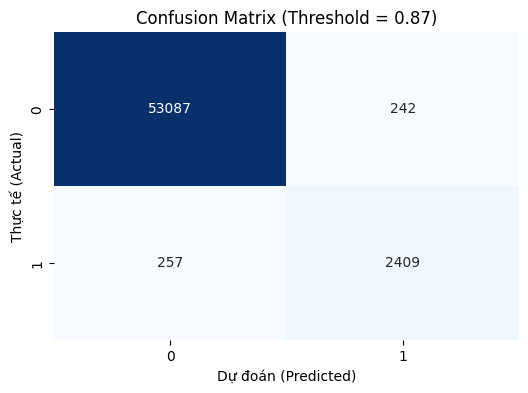

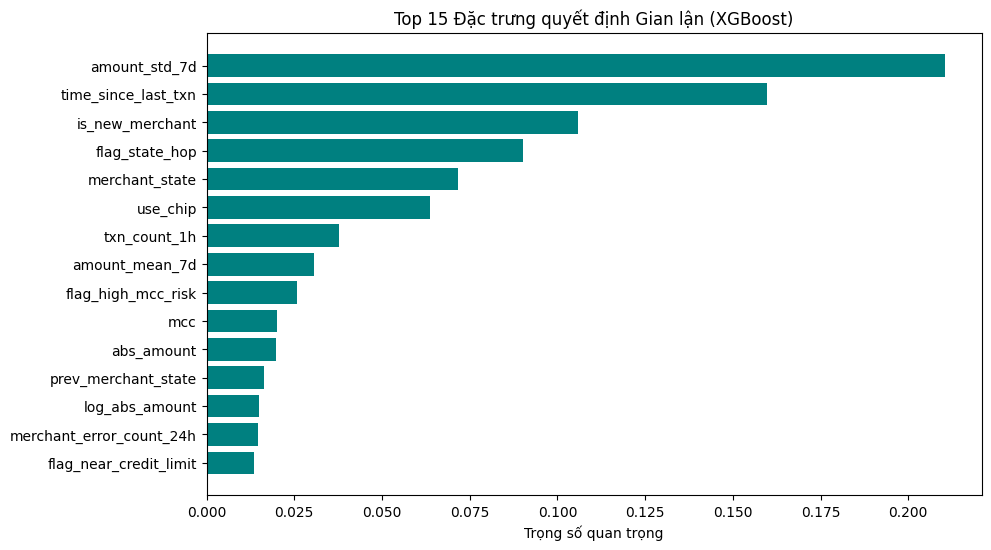

In [10]:
import seaborn as sns

def step4_evaluate(model, X_train, X_test, y_train, y_test):
    print("\n--- BƯỚC 4: ĐÁNH GIÁ MÔ HÌNH ---")

    # 1. Dự đoán xác suất
    y_test_proba = model.predict_proba(X_test)[:, 1]
    y_train_proba = model.predict_proba(X_train)[:, 1]

    # 2. Tính PR-AUC
    p_test, r_test, thresholds = precision_recall_curve(y_test, y_test_proba)
    pr_auc_test = auc(r_test, p_test)

    p_train, r_train, _ = precision_recall_curve(y_train, y_train_proba)
    pr_auc_train = auc(r_train, p_train)

    print(f" -> [ĐIỂM SỐ] PR-AUC (Tập Train): {pr_auc_train:.4f}")
    print(f" -> [ĐIỂM SỐ] PR-AUC (Tập Test) : {pr_auc_test:.4f}")

    # 3. Tìm Ngưỡng (Threshold) tối ưu hóa F1-Score
    f1_scores = 2 * (p_test * r_test) / (p_test + r_test + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5

    print(f"\n=> Ngưỡng cảnh báo tối ưu (Optimal Threshold): {optimal_threshold:.4f}")

    # 4. Báo cáo phân loại
    y_pred_optimal = (y_test_proba >= optimal_threshold).astype(int)
    from sklearn.metrics import classification_report, confusion_matrix
    print("\nBÁO CÁO PHÂN LOẠI:")
    print(classification_report(y_test, y_pred_optimal))

    # 5. Vẽ Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_optimal)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (Actual)')
    plt.title(f'Confusion Matrix (Threshold = {optimal_threshold:.2f})')
    plt.show()

    # 6. Trực quan hóa Feature Importance
    importance = model.feature_importances_
    feat_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': importance})
    feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='teal')
    plt.title("Top 15 Đặc trưng quyết định Gian lận (XGBoost)")
    plt.xlabel("Trọng số quan trọng")
    plt.show()

# Chạy Bước 4
step4_evaluate(model_xgb, X_train, X_test, y_train, y_test)